In [1]:
%matplotlib inline

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

train_img_dir = '/kaggle/input/retina-blood-vessel/Data/train/image'
train_msk_dir = '/kaggle/input/retina-blood-vessel/Data/train/mask'
test_img_dir = '/kaggle/input/retina-blood-vessel/Data/test/image'
test_msk_dir = '/kaggle/input/retina-blood-vessel/Data/test/mask'

2025-04-12 12:36:34.030496: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1744461394.246366      31 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1744461394.310501      31 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
import os
import cv2
from glob import glob

def load_imgs(folder):
    imgs = []

    for file in glob(os.path.join(folder, '*.png')):
        img = cv2.imread(file, cv2.IMREAD_GRAYSCALE)
        imgs.append(img)

    return imgs

def resize_imgs(imgs, size):
    resized_imgs = []

    for img in imgs:
        resized_img = cv2.resize(img, size)
        resized_imgs.append(resized_img)

    return np.array(resized_imgs)

In [3]:
train_imgs = load_imgs(train_img_dir)
train_msks = load_imgs(train_msk_dir)
test_imgs = load_imgs(test_img_dir)
test_msks = load_imgs(test_msk_dir)

train_imgs = resize_imgs(train_imgs, (256, 256))
train_msks = resize_imgs(train_msks, (256, 256))
test_imgs = resize_imgs(test_imgs, (256, 256))
test_msks = resize_imgs(test_msks, (256, 256))

In [4]:
train_imgs = train_imgs / 255
train_msks = train_msks / 255
test_imgs = test_imgs / 255
test_msks = test_msks / 255

train_imgs = tf.expand_dims(train_imgs, axis=-1)
train_msks = tf.expand_dims(train_msks, axis=-1)
test_imgs = tf.expand_dims(test_imgs, axis=-1)
test_msks = tf.expand_dims(test_msks, axis=-1)

print('Shape of train imgs:', train_imgs.shape)
print('Shape of train msks:', train_msks.shape)
print('Shape of test imgs:', test_imgs.shape)
print('Shape of test msks:', test_msks.shape)

Shape of train imgs: (80, 256, 256, 1)
Shape of train msks: (80, 256, 256, 1)
Shape of test imgs: (20, 256, 256, 1)
Shape of test msks: (20, 256, 256, 1)


I0000 00:00:1744461409.849987      31 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


In [5]:
from tensorflow.keras.layers import Input, Conv2D, Dropout, MaxPooling2D, concatenate, UpSampling2D
from tensorflow.keras import Model

def u_net(input_size=(256, 256, 1)):
    inputs = Input(input_size)

    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(inputs)
    conv1 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(conv1)
    pool1 = MaxPooling2D(pool_size=(2, 2))(conv1)

    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(pool1)
    conv2 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(conv2)
    pool2 = MaxPooling2D(pool_size=(2, 2))(conv2)

    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(pool2)
    conv3 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(conv3)
    pool3 = MaxPooling2D(pool_size=(2, 2))(conv3)

    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(pool3)
    conv4 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(conv4)
    drop4 = Dropout(0.5)(conv4)
    pool4 = MaxPooling2D(pool_size=(2, 2))(drop4)

    conv5 = Conv2D(1024, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(pool4)
    conv5 = Conv2D(1024, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(conv5)
    drop5 = Dropout(0.5)(conv5)

    up6 = Conv2D(512, (2, 2), activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(drop5))
    merge6 = concatenate([drop4, up6], axis=3)
    conv6 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(merge6)
    conv6 = Conv2D(512, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(conv6)

    up7 = Conv2D(256, (2, 2), activation='relu', padding='same', kernel_initializer='he_normal')(UpSampling2D(size=(2, 2))(conv6))
    merge7 = concatenate([conv3, up7], axis=3)
    conv7 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(merge7)
    conv7 = Conv2D(256, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(conv7)

    up8 = Conv2D(128, (2, 2), activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv7))
    merge8 = concatenate([conv2, up8], axis=3)
    conv8 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(merge8)
    conv8 = Conv2D(128, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(conv8)

    up9 = Conv2D(64, (2, 2), activation='relu', padding='same')(UpSampling2D(size=(2, 2))(conv8))
    merge9 = concatenate([conv1, up9], axis=3)
    conv9 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(merge9)
    conv9 = Conv2D(64, (3, 3), activation='relu', padding='same', kernel_initializer='he_normal')(conv9)
    conv9 = Conv2D(1, (1, 1), activation='sigmoid', kernel_initializer='glorot_normal')(conv9)

    model = Model(inputs=inputs, outputs=conv9)

    return model

In [6]:
model = u_net()
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 256, 256, 1)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 256, 256, 64)   │            640 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 256, 256, 64)   │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 128, 128, 64)   │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 128, 128, 128)  │         73,856 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 128, 128, 128)  │        147,584 │ conv2d_2[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_1           │ (None, 64, 64, 128)    │              0 │ conv2d_3[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 64, 64, 256)    │        295,168 │ max_pooling2d_1[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 64, 64, 256)    │        590,080 │ conv2d_4[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_2           │ (None, 32, 32, 256)    │              0 │ conv2d_5[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 32, 32, 512)    │      1,180,160 │ max_pooling2d_2[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 32, 32, 512)    │      2,359,808 │ conv2d_6[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout (Dropout)         │ (None, 32, 32, 512)    │              0 │ conv2d_7[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d_3           │ (None, 16, 16, 512)    │              0 │ dropout[0][0]          │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 16, 16, 1024)   │      4,719,616 │ max_pooling2d_3[0][0]  │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 16, 16, 1024)   │      9,438,208 │ conv2d_8[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ dropout_1 (Dropout)       │ (None, 16, 16, 1024)   │              0 │ conv2d_9[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ up_sampling2d        

 Total params: 31,030,593 (118.37 MB)

 Trainable params: 31,030,593 (118.37 MB)

 Non-trainable params: 0 (0.00 B)

In [7]:
from tensorflow.keras.optimizers import AdamW
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from keras.metrics import MeanIoU

num_epochs = 100

lr_scheduler = ExponentialDecay(initial_learning_rate=3e-3, decay_steps=num_epochs, decay_rate=0.98)
optimizer = AdamW(learning_rate=lr_scheduler, weight_decay=1e-6)

model.compile(
    optimizer=optimizer,
    loss='binary_crossentropy',
    metrics=['accuracy', MeanIoU(num_classes=2, name='iou')]
)

In [8]:
train_log = model.fit(
    train_imgs,
    train_msks,
    validation_data=(test_imgs, test_msks),
    epochs=num_epochs,
    batch_size=8
)

Epoch 1/100


I0000 00:00:1744461423.023250      90 service.cc:148] XLA service 0x7abfc80024c0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1744461423.024024      90 service.cc:156]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1744461424.146123      90 cuda_dnn.cc:529] Loaded cuDNN version 90300
I0000 00:00:1744461449.379987      90 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 246ms/step - accuracy: 0.5986 - iou: 0.4852 - loss: 2513146.5000

E0000 00:00:1744461464.147640      90 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1744461464.405108      90 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


10/10 ━━━━━━━━━━━━━━━━━━━━ 57s 2s/step - accuracy: 0.6128 - iou: 0.4852 - loss: 2403119.0000 - val_accuracy: 0.8388 - val_iou: 0.4851 - val_loss: 0.4281
Epoch 2/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 273ms/step - accuracy: 0.8413 - iou: 0.4853 - loss: 0.4696 - val_accuracy: 0.8388 - val_iou: 0.4851 - val_loss: 0.4544
Epoch 3/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 273ms/step - accuracy: 0.8344 - iou: 0.4850 - loss: 0.4266 - val_accuracy: 0.8388 - val_iou: 0.4851 - val_loss: 0.2837
Epoch 4/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 274ms/step - accuracy: 0.8420 - iou: 0.4856 - loss: 0.2745 - val_accuracy: 0.8388 - val_iou: 0.4851 - val_loss: 0.2740
Epoch 5/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 273ms/step - accuracy: 0.8375 - iou: 0.4853 - loss: 0.2749 - val_accuracy: 0.8388 - val_iou: 0.4851 - val_loss: 0.2635
Epoch 6/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 273ms/step - accuracy: 0.8409 - iou: 0.4853 - loss: 0.2644 - val_accuracy: 0.8388 - val_iou: 0.4851 - val_loss: 0.2609
Epoch 7/100
10/10 ━━━━━━━━━━━━━━━━━━━━ 3s 

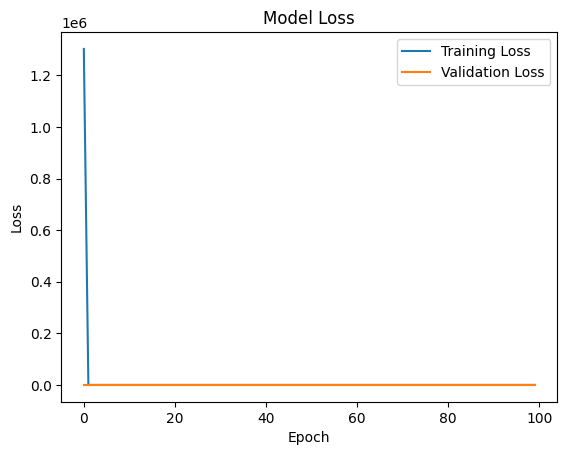

In [9]:
epochs = range(num_epochs)
train_loss = train_log.history['loss']
val_loss = train_log.history['val_loss']
train_acc = train_log.history['accuracy']
val_acc = train_log.history['val_accuracy']

plt.plot(epochs, train_loss, label="Training Loss")
plt.plot(epochs, val_loss, label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Model Loss")
plt.legend()
plt.show()

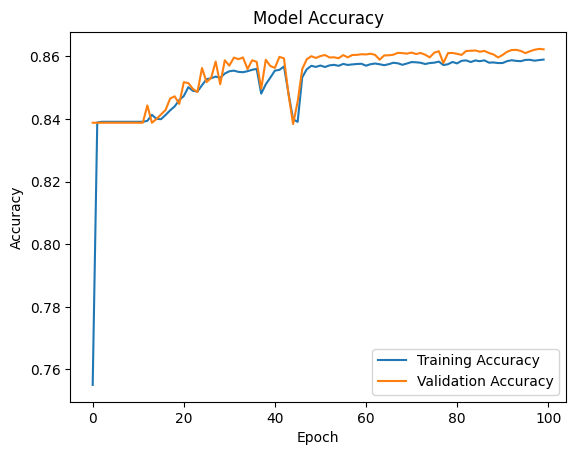

In [10]:
plt.plot(epochs, train_acc, label="Training Accuracy")
plt.plot(epochs, val_acc, label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Model Accuracy")
plt.legend()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


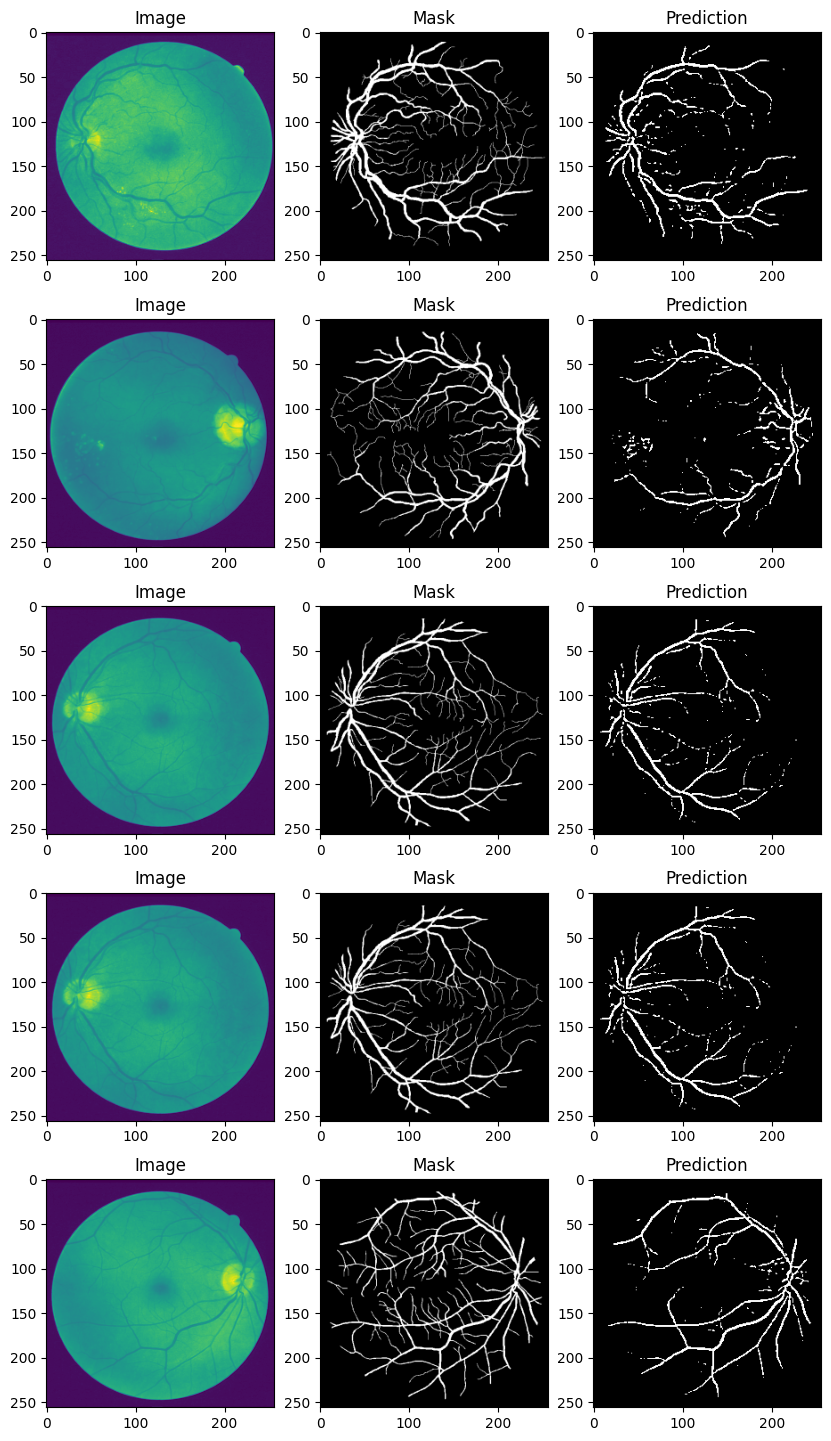

In [11]:
fig, ax = plt.subplots(5, 3, figsize=(10, 18))

j = np.random.randint(0, test_imgs.shape[0], 5)

for i in range(5):
    ax[i, 0].imshow(test_imgs[j[i]])
    ax[i, 0].set_title('Image')
    ax[i, 1].imshow(test_msks[j[i]], cmap='gray')
    ax[i, 1].set_title('Mask')
    
    y_pred = model.predict(np.expand_dims(test_imgs[j[i]], 0))[0]
    
    binary_msk = (y_pred >= 0.5).astype(np.uint8)
    
    ax[i, 2].imshow(binary_msk, cmap='gray')
    ax[i, 2].set_title('Prediction')
    
plt.show()